# Smart Grid Edge AI — Visual Results

This notebook presents portfolio-ready visualizations for the adaptive edge–cloud smart-grid EMS. All results shown here come from the repository's reproducible **synthetic-data validation** and are not claims of field performance.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from smartgrid_ems.config import load_config
from smartgrid_ems.data import generate_synthetic_grid_data
from smartgrid_ems.features import engineer_features, FEATURES
from smartgrid_ems.models import train_models
from smartgrid_ems.controller import run_controller

config = load_config(ROOT / "config" / "default.yaml")
raw = generate_synthetic_grid_data(seed=config["seed"], **config["data"])
data = engineer_features(raw)
forecast = pd.read_csv(ROOT / "reports" / "research" / "forecast_benchmarks.csv")
ablation = pd.read_csv(ROOT / "reports" / "research" / "ablation_study.csv")
anomaly = pd.read_csv(ROOT / "reports" / "research" / "anomaly_benchmarks.csv")
importance = pd.read_csv(ROOT / "reports" / "research" / "feature_importance.csv")
print(f"Telemetry rows: {len(raw):,}; engineered rows: {len(data):,}")

Telemetry rows: 2,880; engineered rows: 2,876


## 1. Smart-grid telemetry

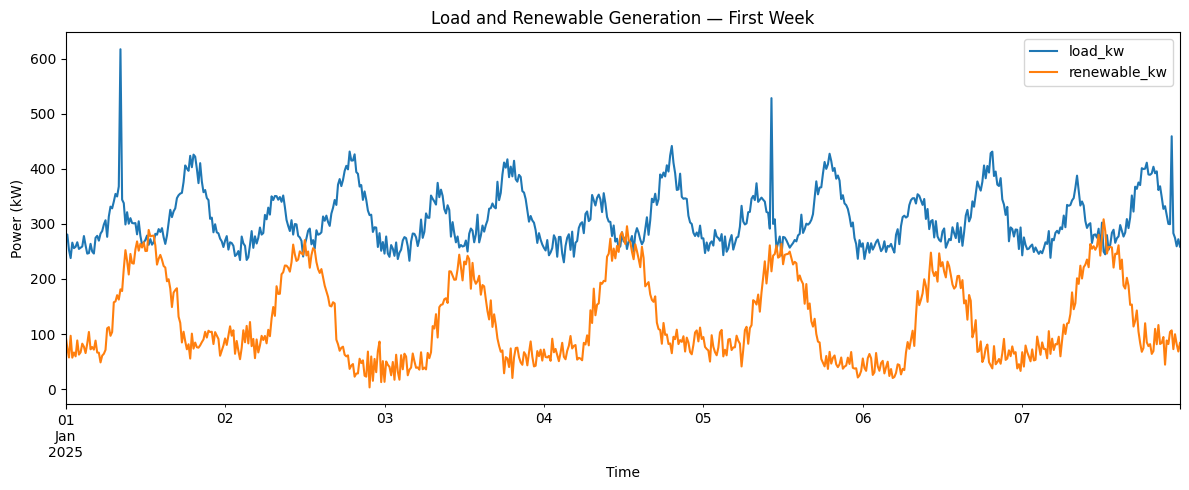

In [2]:
week = raw.iloc[:7*24*4]
ax = week.plot(x="timestamp", y=["load_kw", "renewable_kw"], figsize=(12,5), title="Load and Renewable Generation — First Week")
ax.set_ylabel("Power (kW)")
ax.set_xlabel("Time")
plt.tight_layout()
plt.show()

## 2. Forecasting model comparison

,model,mae_kw,rmse_kw,r2,inference_ms_per_sample,serialized_size_kb
4,hist_gradient_boosting,13.275191,22.500051,0.832937,0.008231,720.614258
3,extra_trees,13.682399,25.780592,0.780669,0.087091,23957.739258
2,random_forest,13.783154,26.289813,0.771919,0.044629,1502.056641
5,lstm,14.725093,30.358410,0.695861,0.001320,30.663086
1,ridge,17.076446,29.829383,0.706368,0.000904,1.753906
0,persistence_lag1,21.397684,42.238841,0.411240,0.000000,0.000000


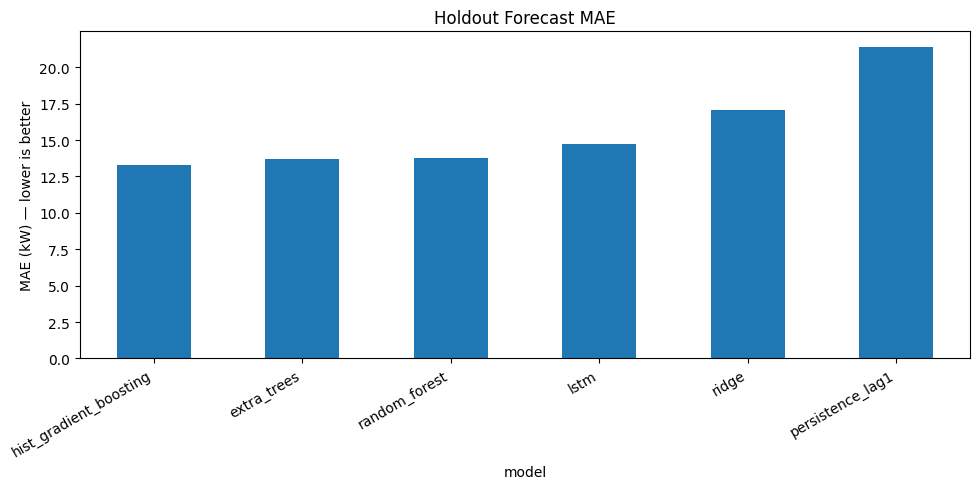

In [3]:
display(forecast[["model", "mae_kw", "rmse_kw", "r2", "inference_ms_per_sample", "serialized_size_kb"]].sort_values("mae_kw"))
ax = forecast.sort_values("mae_kw").plot.bar(x="model", y="mae_kw", figsize=(10,5), legend=False, title="Holdout Forecast MAE")
ax.set_ylabel("MAE (kW) — lower is better")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

The single-holdout benchmark shows that HistGradientBoosting provides the lowest MAE in this synthetic validation run, while the broader research suite also reports rolling time-series stability.

## 3. Accuracy–latency trade-off

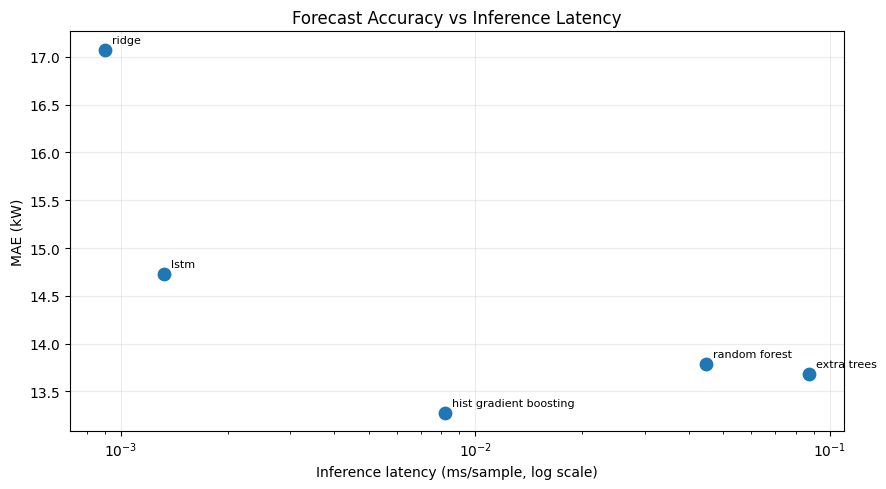

In [4]:
eff = forecast[forecast["model"] != "persistence_lag1"].copy()
fig, ax = plt.subplots(figsize=(9,5))
ax.scatter(eff["inference_ms_per_sample"], eff["mae_kw"], s=80)
for _, r in eff.iterrows():
    ax.annotate(r["model"].replace("_", " "), (r["inference_ms_per_sample"], r["mae_kw"]), xytext=(5,5), textcoords="offset points", fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Inference latency (ms/sample, log scale)")
ax.set_ylabel("MAE (kW)")
ax.set_title("Forecast Accuracy vs Inference Latency")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Feature-ablation study

,experiment,n_features,mae_kw,rmse_kw,r2
2,no_grid_state_features,13,13.662172,26.224319,0.773054
0,full_features,18,13.682399,25.780592,0.780669
1,no_temporal_features,11,14.007818,26.560834,0.767192
3,no_communication_features,15,14.512734,29.831219,0.706332


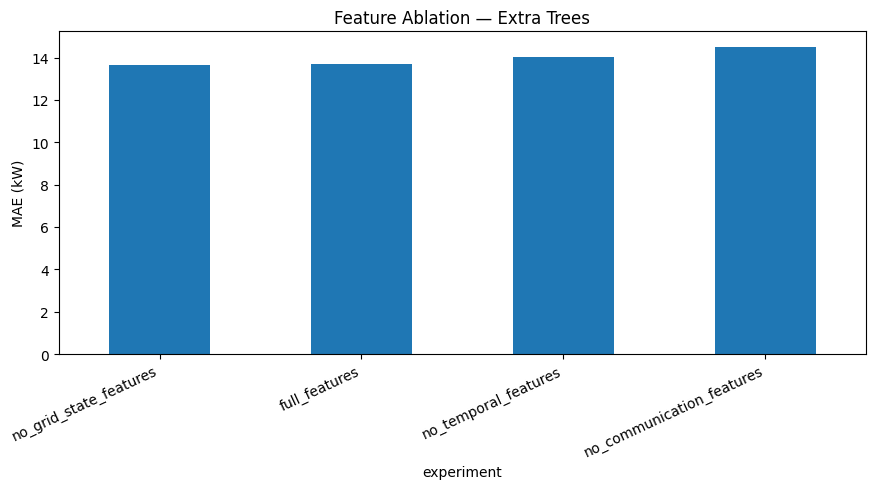

In [5]:
display(ablation[["experiment", "n_features", "mae_kw", "rmse_kw", "r2"]].sort_values("mae_kw"))
ax = ablation.sort_values("mae_kw").plot.bar(x="experiment", y="mae_kw", figsize=(9,5), legend=False, title="Feature Ablation — Extra Trees")
ax.set_ylabel("MAE (kW)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 5. Feature importance

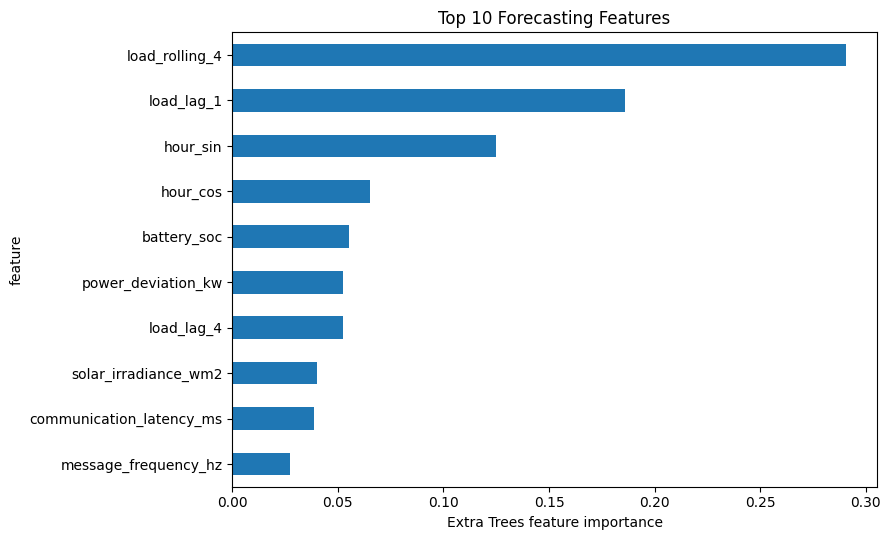

In [6]:
top = importance.head(10).sort_values("importance")
ax = top.plot.barh(x="feature", y="importance", figsize=(9,5.5), legend=False, title="Top 10 Forecasting Features")
ax.set_xlabel("Extra Trees feature importance")
plt.tight_layout()
plt.show()

## 6. Anomaly-detector comparison

,detector,precision,recall,f1,predicted_anomaly_rate
2,one_class_svm,0.315789,1.000000,0.480000,0.131944
1,isolation_forest,0.207207,0.958333,0.340741,0.192708
0,statistical,0.109091,1.000000,0.196721,0.381944


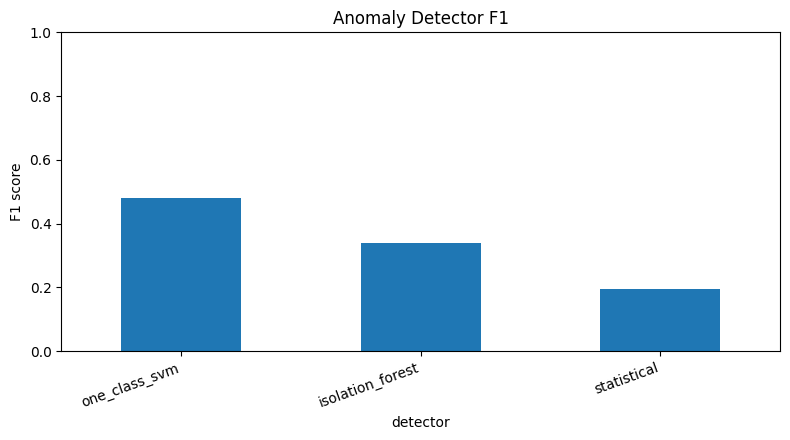

In [7]:
display(anomaly.sort_values("f1", ascending=False))
ax = anomaly.sort_values("f1", ascending=False).plot.bar(x="detector", y="f1", figsize=(8,4.5), legend=False, title="Anomaly Detector F1")
ax.set_ylim(0,1)
ax.set_ylabel("F1 score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 7. Adaptive edge–cloud routing

{'edge_mae_kw': 13.81025581969653, 'edge_rmse_kw': 26.30600290384484, 'cloud_mae_kw': 13.679710942901345, 'cloud_rmse_kw': 25.851941751313117}
Cloud escalation rate: 5.90%


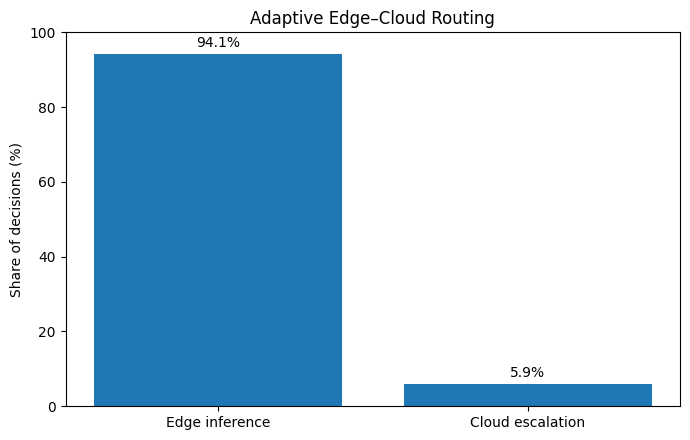

In [8]:
bundle, metrics = train_models(data, config)
split = int(len(data)*0.8)
decisions = run_controller(data.iloc[split:], bundle, config)
cloud_rate = 100 * decisions["escalated_to_cloud"].mean()
edge_rate = 100 - cloud_rate
print(metrics)
print(f"Cloud escalation rate: {cloud_rate:.2f}%")
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(["Edge inference", "Cloud escalation"], [edge_rate, cloud_rate])
ax.set_ylim(0,100)
ax.set_ylabel("Share of decisions (%)")
ax.set_title("Adaptive Edge–Cloud Routing")
for i, v in enumerate([edge_rate, cloud_rate]):
    ax.text(i, v+2, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

## Interpretation

The visual results support the core engineering story of the project: multiple forecasting baselines are compared under chronological validation, model accuracy is considered alongside inference cost, feature groups are tested through ablation, anomaly detectors are benchmarked separately, and the controller keeps most routine decisions at the edge while escalating selected cases to cloud processing.